#Sentiment Analysis on IMDB Movie Reviews using NLP and Machine Learning
Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine whether a piece of text expresses a positive or negative sentiment. It is widely used in review analysis, customer feedback systems, social media monitoring, and recommendation systems.

In this project, we use the IMDB Movie Reviews Dataset to build a sentiment classification model. The project includes:

Text preprocessing
Data cleaning
TF-IDF vectorization
Machine Learning model training
Performance evaluation
Prediction on custom reviews

This project demonstrates how AI and NLP can be used to automatically understand human opinions from textual data.

Step 1: Import Libraries and Download Stopwords

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

his step imports all required libraries for:

Data handling
Text preprocessing
Machine learning
Visualization
Performance evaluation

Step 2: Load Dataset

In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


This step loads the CSV dataset into a pandas DataFrame and displays the first 5 rows

Step 3: Dataset Information and Missing Values

In [ ]:
df.info()

print("\nMissing Values:\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing Values:

review       0
sentiment    0
dtype: int64


This step checks:

Number of rows and columns
Data types
Missing values in the dataset

Step 5: Convert Labels and Preprocess Text
Code


In [ ]:
import numpy as np

# Convert sentiment labels to numerical values (1 for positive, 0 for negative)
df['sentiment'] = np.where(df['sentiment'] == 'positive', 1, 0)

# Initialize stemmer and stopwords
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

# Text preprocessing function
def preprocess_text(text):

    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', str(text))

    # Convert text to lowercase
    text = text.lower()

    # Split text into words
    words = text.split()

    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

df[['review', 'clean_review', 'sentiment']].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...,1
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...,1
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...,1
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...,1


This step:

Converts labels into

numerical values

Cleans the text

Removes stopwords

Applies stemming

This improves model performance and accuracy

Step 5: TF-IDF Vectorization and Train-Test Split

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (40000, 5000)
Testing Data Shape: (10000, 5000)


TF-IDF converts text data into numerical vectors.

The dataset is divided into:

80% training data
20% testing data

Step 6: Train the Naive Bayes Model

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Training Completed")

Model Training Completed


The Naive Bayes algorithm is trained on movie review data to classify sentiments as positive or negative.

Step 7: Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:\n")

print(accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy Score:

0.8516

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



This step evaluates the model using:

Accuracy
Precision
Recall
F1-score

Higher values indicate better model performance

Step 8: Confusion Matrix Visualization

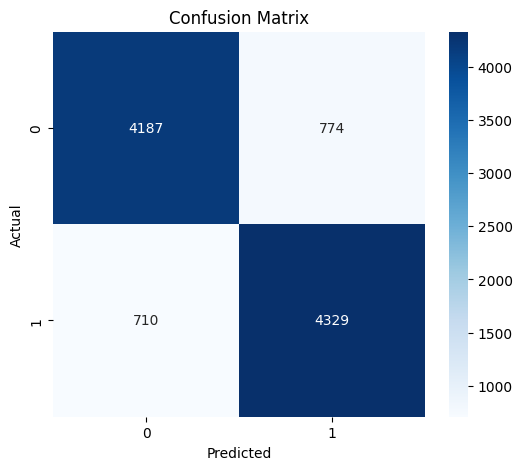

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows:

Correct predictions
Incorrect predictions

Better diagonal values indicate higher accuracy

Step 9: Sentiment Distribution Graph

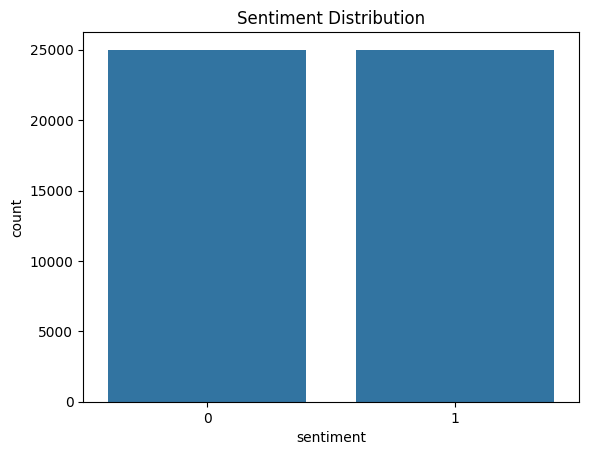

In [ ]:
sns.countplot(x=df['sentiment'])

plt.title("Sentiment Distribution")

plt.show()

This graph shows the distribution of:

Positive reviews
Negative reviews

in the dataset.

Step 10: Custom Review Prediction

In [ ]:
sample_review = "This movie was absolutely fantastic and amazing"

sample_review = preprocess_text(sample_review)

sample_vector = tfidf.transform([sample_review]).toarray()

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Review 😊")

else:
    print("Negative Review 😔")

Positive Review 😊


This step tests the model on a new custom review entered by the user

#Conclusion

In this project, we successfully developed a Sentiment Analysis system using:

Natural Language Processing (NLP)

TF-IDF Vectorization

Naive Bayes Machine

Learning Algorithm

The model achieved good accuracy in classifying movie reviews as positive or negative.

This project demonstrates how Artificial Intelligence can understand human emotions and opinions from textual data.